## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from datetime import datetime
import os

## EDA

In [2]:
train_path = 'data/train_ML_IOT.csv'
os.path.exists(train_path)

True

In [3]:
train = pd.read_csv(train_path)

In [4]:
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [5]:
train.shape

(48120, 4)

In [6]:
train.dtypes

DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object

In [7]:
train.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


No null values

In [9]:
train.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

<Axes: >

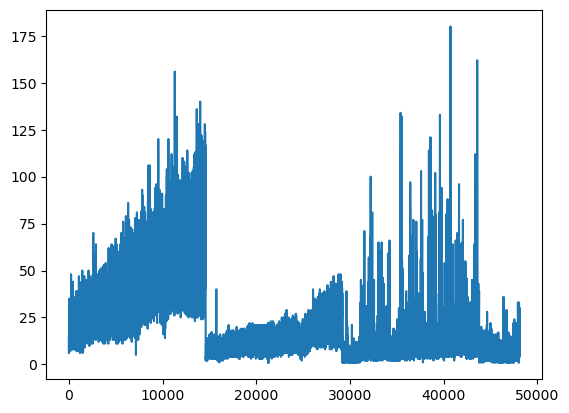

In [10]:
train['Vehicles'].plot()

In [11]:
print(f"Number of rows before dropping duplicates: {train.shape[0]}")
train.drop_duplicates(keep="first", inplace=True)
print(f"Number of rows after dropping duplicates: {train.shape[0]}")


Number of rows before dropping duplicates: 48120
Number of rows after dropping duplicates: 48120


Drop the ID column

In [12]:
train.drop(["ID"], inplace=True, axis=1)

In [13]:
train.head()

,DateTime,Junction,Vehicles
0,2015-11-01 00:00:00,1,15
1,2015-11-01 01:00:00,1,13
2,2015-11-01 02:00:00,1,10
3,2015-11-01 03:00:00,1,7
4,2015-11-01 04:00:00,1,9


## Feature Engineering

In [14]:
train['DateTime'] = pd.to_datetime(train['DateTime'])
train = train.sort_values(by='DateTime')

In [ ]:
train['Hour'] = train['DateTime'].dt.hour
train['Weekday'] = train['DateTime'].dt.weekday
train['Day'] = train['DateTime'].dt.day
train['Month'] = train['DateTime'].dt.month
train['Week'] = train['DmateTime'].dt.isocalendar().week.astype(int)

In [16]:
train.head()

,DateTime,Junction,Vehicles,Hour,Weekday,Day,Month,Week
0,2015-11-01 00:00:00,1,15,0,6,1,11,44
14592,2015-11-01 00:00:00,2,6,0,6,1,11,44
29184,2015-11-01 00:00:00,3,9,0,6,1,11,44
29185,2015-11-01 01:00:00,3,7,1,6,1,11,44
1,2015-11-01 01:00:00,1,13,1,6,1,11,44


## Visualization

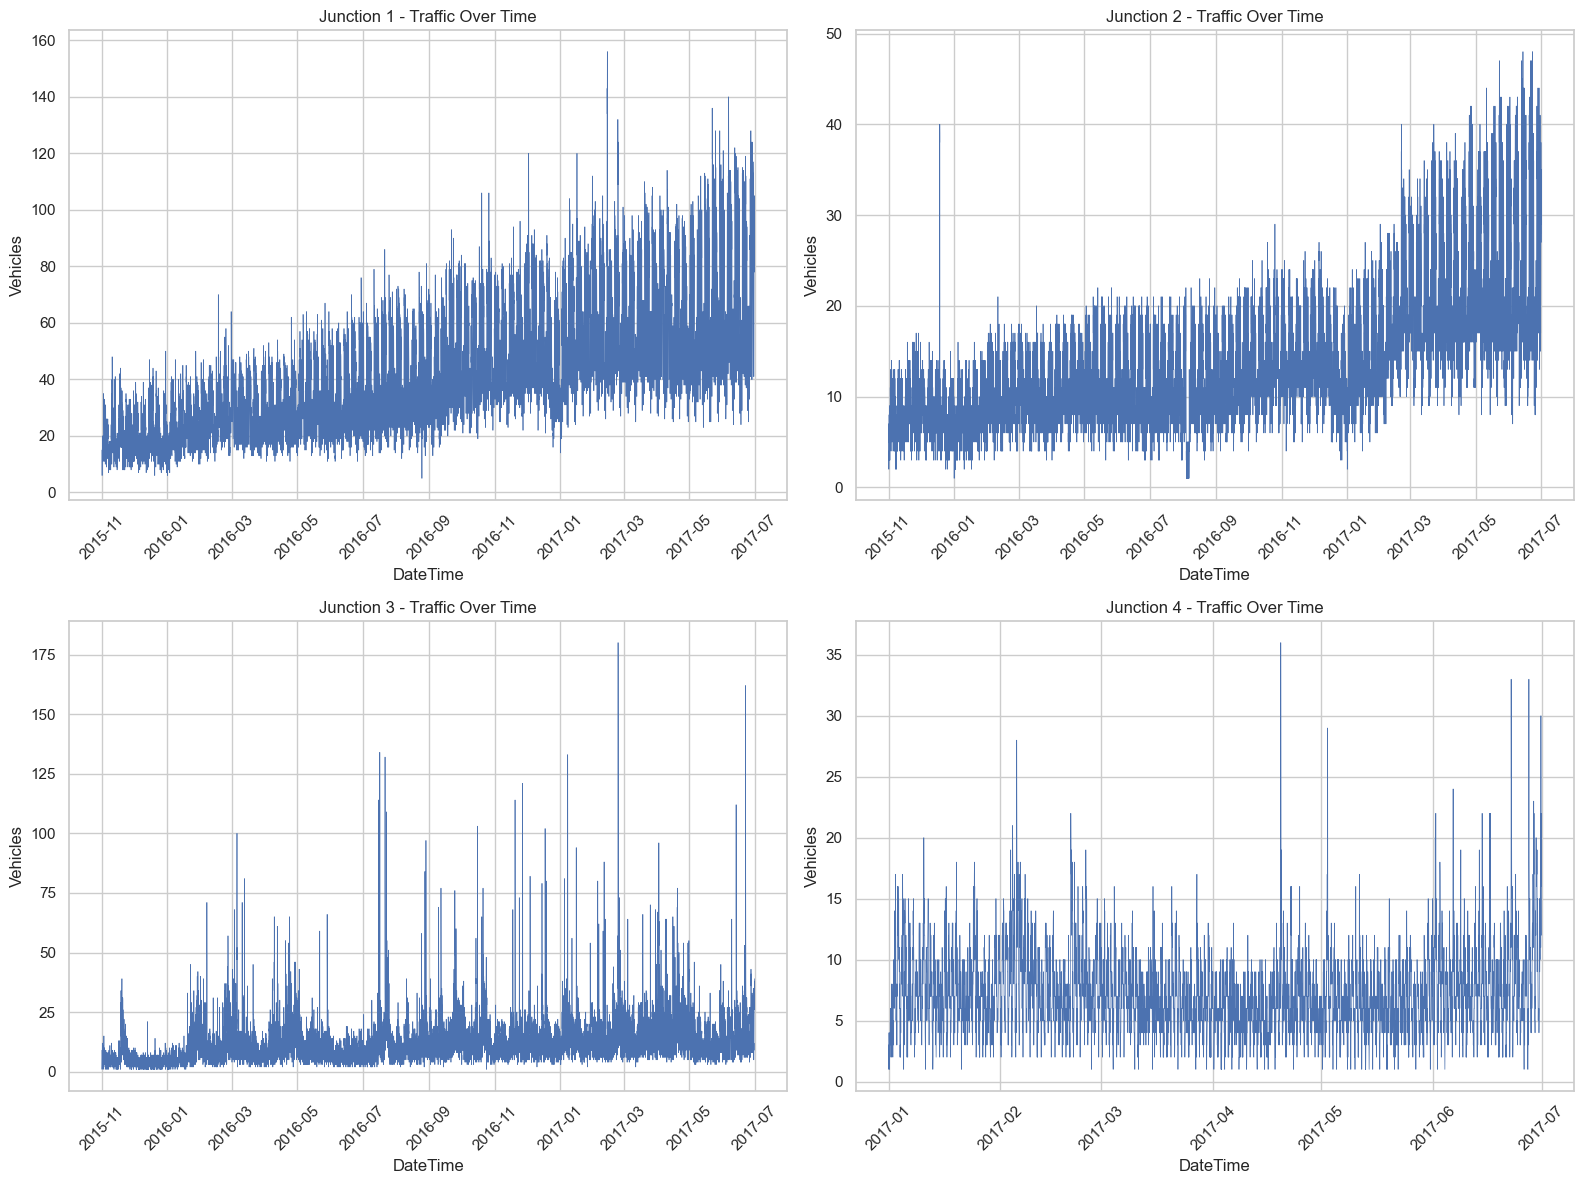

In [17]:

sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Unique junctions
junctions = train['Junction'].unique()

# Create subplots
for i, junc in enumerate(sorted(junctions), 1):
    plt.subplot(2, 2, i)
    subset = train[train['Junction'] == junc]
    sns.lineplot(x='DateTime', y='Vehicles', data=subset, linewidth=0.5)
    plt.title(f'Junction {junc} - Traffic Over Time')
    plt.xlabel('DateTime')
    plt.ylabel('Vehicles')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


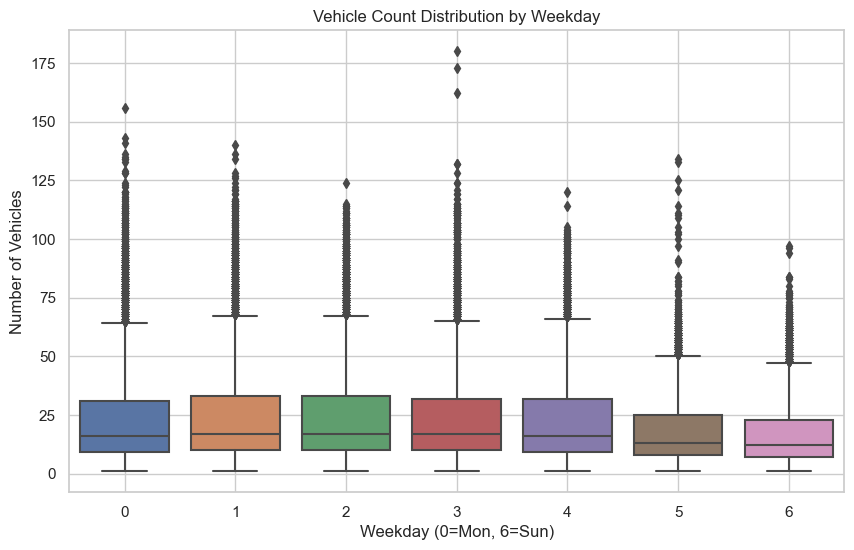

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weekday', y='Vehicles', data=train)
plt.title('Vehicle Count Distribution by Weekday')
plt.xlabel('Weekday (0=Mon, 6=Sun)')
plt.ylabel('Number of Vehicles')
plt.grid(True)
plt.show()

/tmp/ipykernel_80064/2486849842.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='Hour', y='Vehicles', estimator='mean', ci=None)
/tmp/ipykernel_80064/2486849842.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='Hour', y='Vehicles', estimator='mean', ci=None)
/tmp/ipykernel_80064/2486849842.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='Hour', y='Vehicles', estimator='mean', ci=None)
/tmp/ipykernel_80064/2486849842.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='Hour', y='Vehicles', estimator='mean', ci=None)


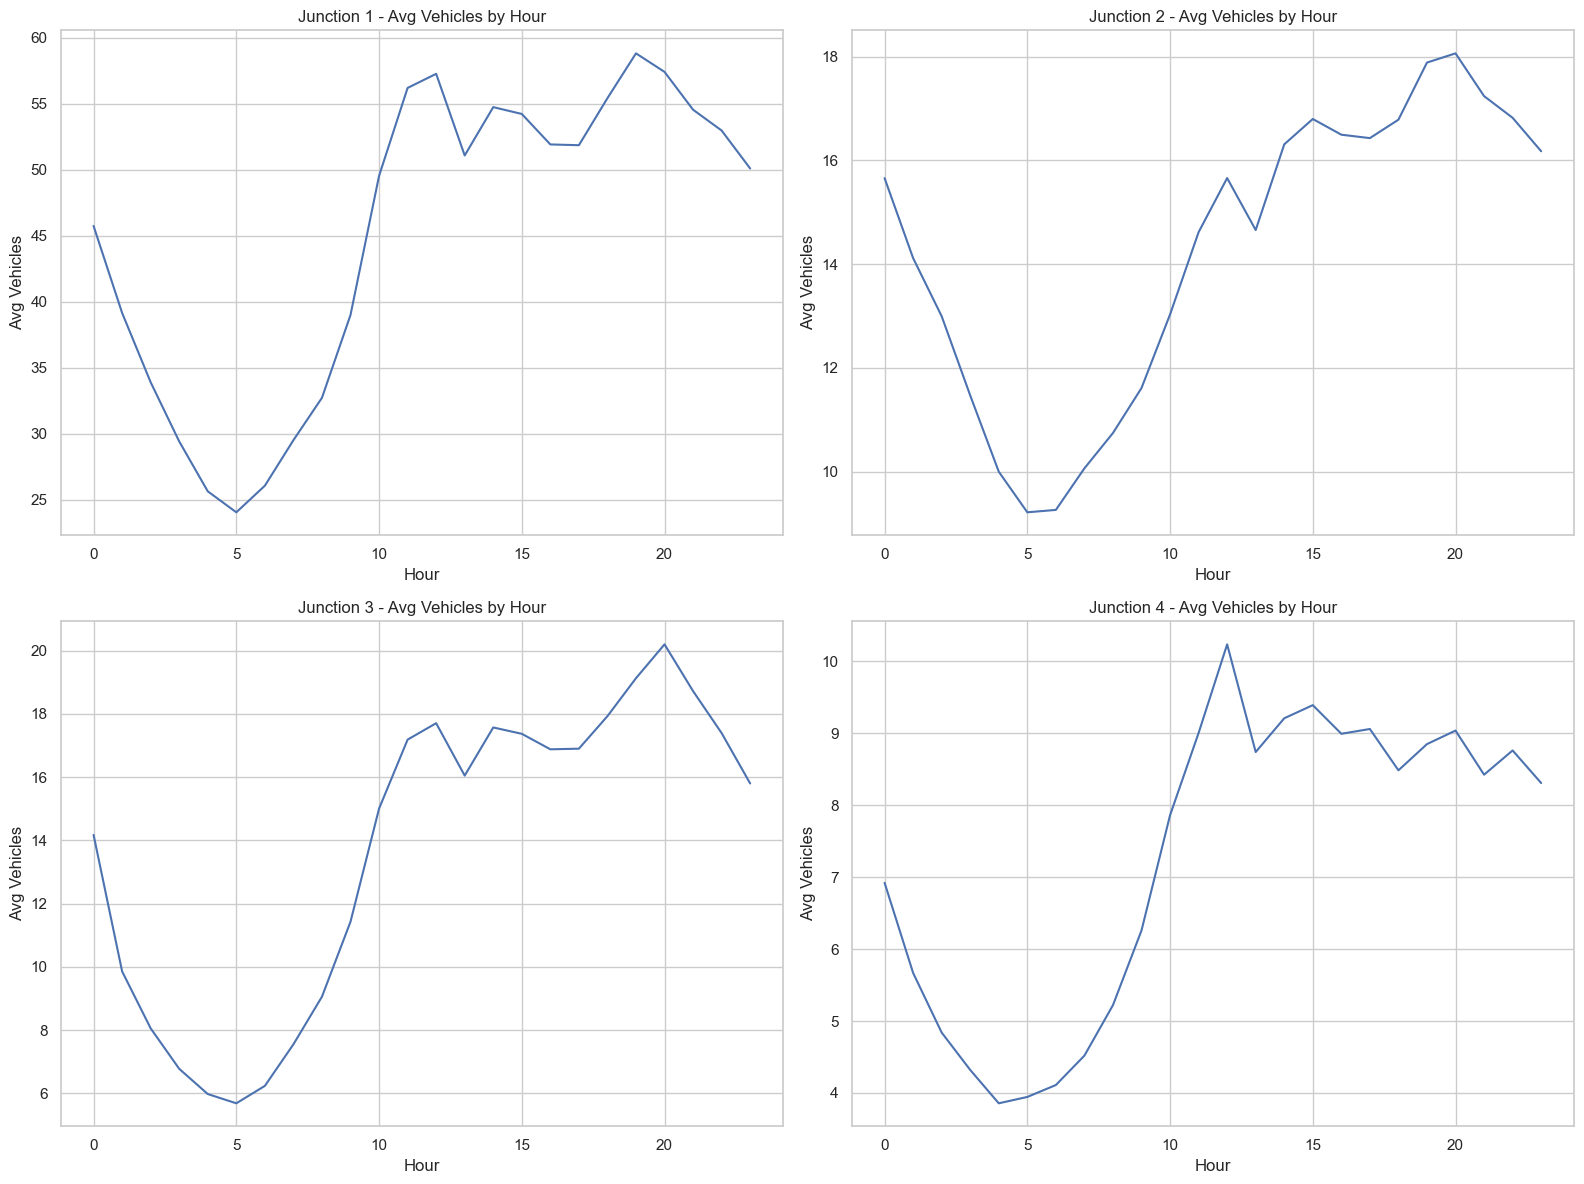

In [19]:
plt.figure(figsize=(16, 12))
for i, junc in enumerate(sorted(junctions), 1):
    plt.subplot(2, 2, i)
    subset = train[train['Junction'] == junc]
    sns.lineplot(data=subset, x='Hour', y='Vehicles', estimator='mean', ci=None)
    plt.title(f'Junction {junc} - Avg Vehicles by Hour')
    plt.xlabel('Hour')
    plt.ylabel('Avg Vehicles')
    plt.grid(True)

plt.tight_layout()
plt.show()

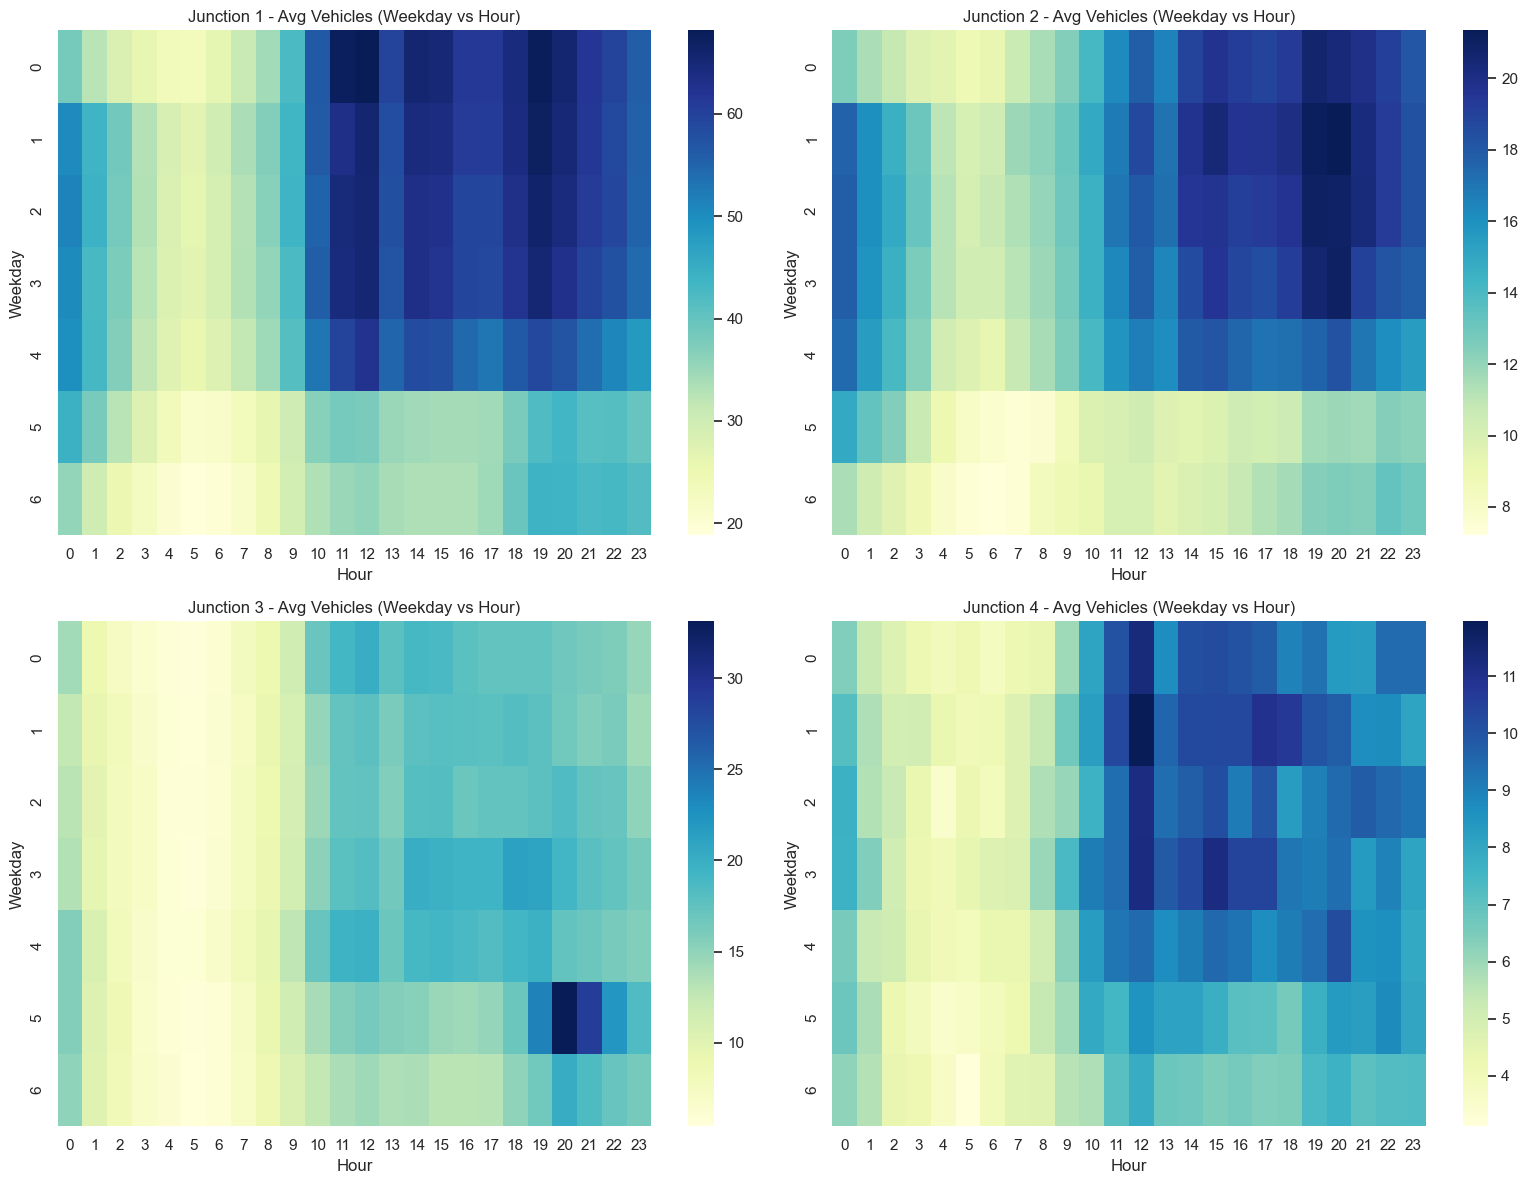

In [20]:
plt.figure(figsize=(16, 12))
for i, junc in enumerate(sorted(junctions), 1):
    plt.subplot(2, 2, i)
    subset = train[train['Junction'] == junc]
    pivot = subset.groupby(['Weekday', 'Hour'])['Vehicles'].mean().unstack()
    sns.heatmap(pivot, cmap='YlGnBu')
    plt.title(f'Junction {junc} - Avg Vehicles (Weekday vs Hour)')
    plt.xlabel('Hour')
    plt.ylabel('Weekday')

plt.tight_layout()
plt.show()


## Train/Test Split

In [21]:
cutoff_date = train['DateTime'].max() - pd.DateOffset(months=4)
train_data = train[train['DateTime'] <= cutoff_date]
val_data = train[train['DateTime'] > cutoff_date]

## Train model for each junction

In [22]:
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'Hour', 'Weekday', 'Day', 'Month',
       'Week'],
      dtype='object')

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

In [24]:
best_models = {}
best_params = {}

features = ['Hour', 'Weekday', 'Day', 'Month', 'Week']


In [25]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
}

In [26]:

for junc in sorted(train['Junction'].unique()):
    print(f"Training model for junction {junc}")
    
    train_j = train_data[train_data['Junction'] == junc]
    val_j = val_data[val_data['Junction'] == junc]
    
    X = train_j[features]
    y = train_j['Vehicles']
    
    # Time based split
    tcvs = TimeSeriesSplit(n_splits=3)
    
    
    
    model = XGBRegressor(random_state=42)
    grid = GridSearchCV(model, param_grid, scoring=rmse_scorer, cv=tcvs, verbose=0)
    grid.fit(X, y)    
    
    print(f"Best RMSE: {-grid.best_score_:.2f}")
    print(f"Best Params: {grid.best_params_}")
    
    best_models[junc] = grid.best_estimator_
    best_params[junc] = grid.best_params_
        
    

Training model for junction 1
Best RMSE: 17.42
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}
Training model for junction 2
Best RMSE: 4.29
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Training model for junction 3
Best RMSE: 11.04
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Training model for junction 4
Best RMSE: 2.73
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1}


/tmp/ipykernel_80064/1918706260.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/home/lok/anaconda3/envs/ML_ENV/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


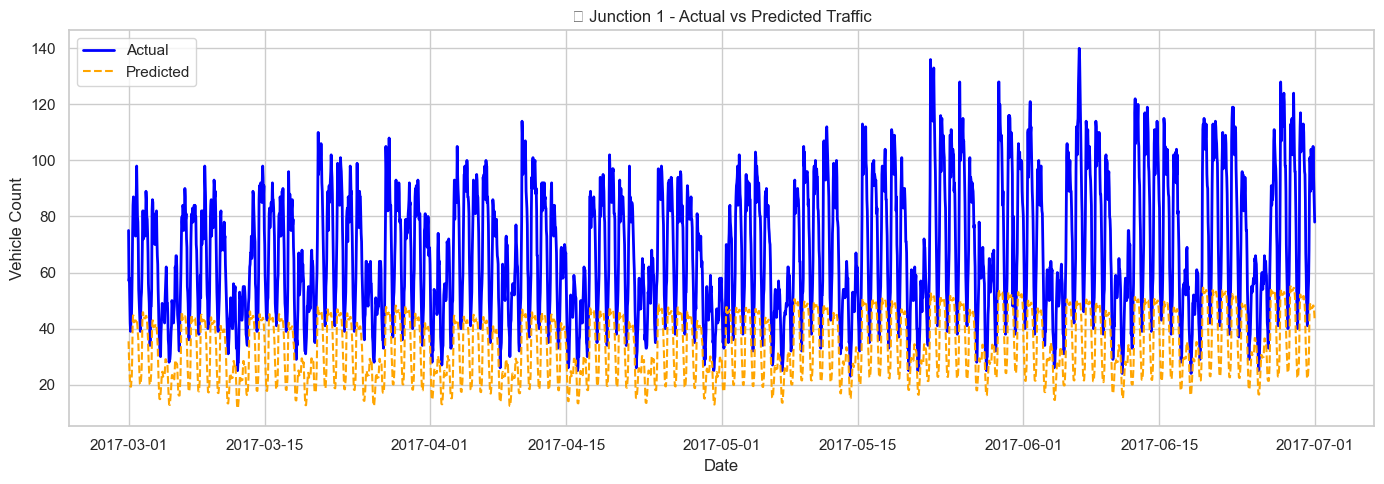

/tmp/ipykernel_80064/1918706260.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/home/lok/anaconda3/envs/ML_ENV/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


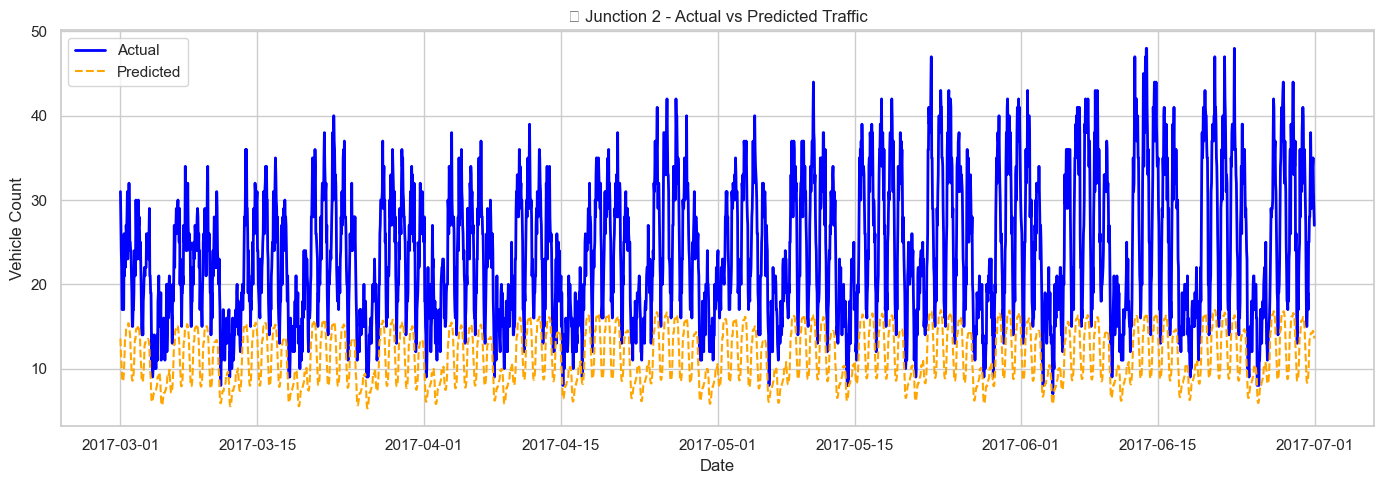

/tmp/ipykernel_80064/1918706260.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/home/lok/anaconda3/envs/ML_ENV/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


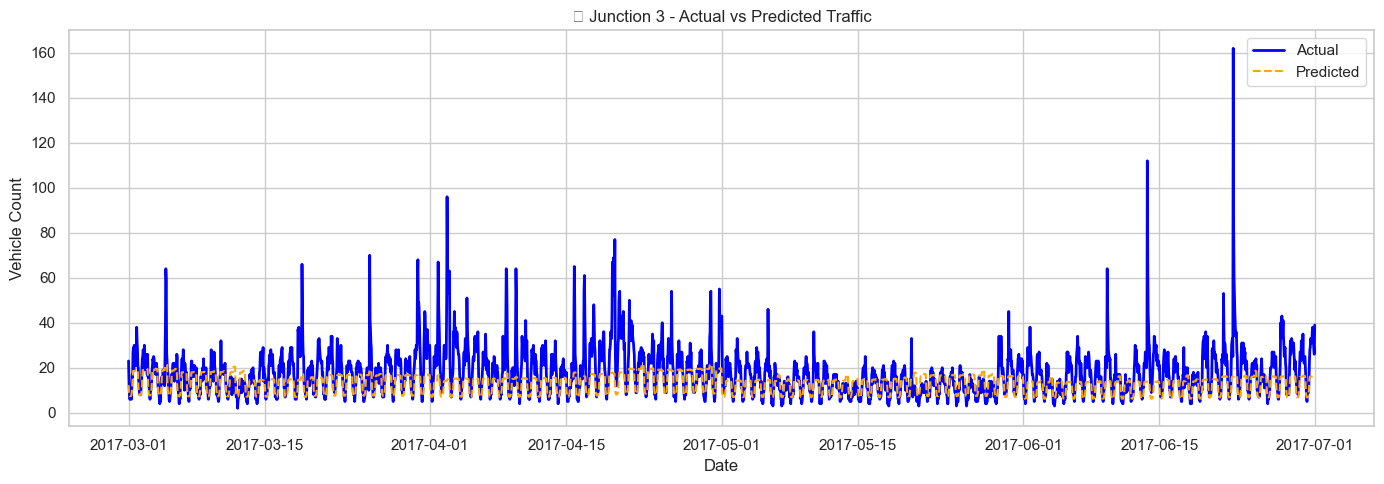

/tmp/ipykernel_80064/1918706260.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/home/lok/anaconda3/envs/ML_ENV/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


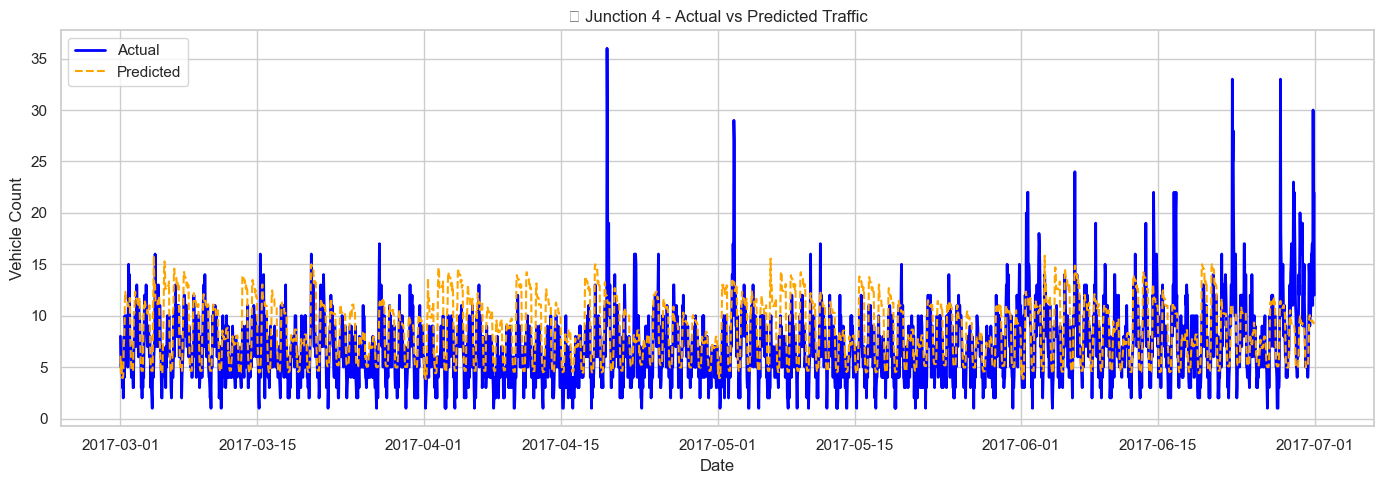

In [27]:
sns.set(style="whitegrid", palette="muted")

# Plot predictions vs actual for each junction
for junc in sorted(val_data['Junction'].unique()):
    val_j = val_data[val_data['Junction'] == junc].copy()
    model = best_models[junc]

    X_val = val_j[features]
    y_val = val_j['Vehicles']
    val_j['Predicted'] = model.predict(X_val)

    plt.figure(figsize=(14, 5))
    plt.plot(val_j['DateTime'], y_val, label='Actual', color='blue', linewidth=2)
    plt.plot(val_j['DateTime'], val_j['Predicted'], label='Predicted', color='orange', linestyle='--')
    plt.title(f'📊 Junction {junc} - Actual vs Predicted Traffic')
    plt.xlabel('Date')
    plt.ylabel('Vehicle Count')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [28]:
print("\n📉 RMSE on Validation Set:")
for junc in sorted(val_data['Junction'].unique()):
    val_j = val_data[val_data['Junction'] == junc].copy()
    model = best_models[junc]
    preds = model.predict(val_j[features])
    rmse = np.sqrt(mean_squared_error(val_j['Vehicles'], preds))
    print(f"Junction {junc}: RMSE = {rmse:.2f}")


📉 RMSE on Validation Set:
Junction 1: RMSE = 35.94
Junction 2: RMSE = 13.42
Junction 3: RMSE = 9.72
Junction 4: RMSE = 3.51
